In [1]:
import os
import sys
ROOT = ".." # Base directory relative to this notebook's location. Adjust if the notebook is moved
sys.path.append(ROOT)
CSV_DIR = os.path.join(ROOT, "csv")
STATS_DIR = os.path.join(CSV_DIR, "stats")
JSON_DIR = os.path.join(ROOT, "json")
MAPS_DIR = os.path.join(ROOT, "maps")
GEO_DATA_PATH = os.path.join(JSON_DIR, "location-metadata.json")
import pandas as pd
import geopandas as gpd
MAP = gpd.read_file(os.path.join(MAPS_DIR, "ne_110m_admin_0_countries.gpkg"))
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import contextily as ctx
import truststore
truststore.inject_into_ssl()

In [2]:
master_geo_data = pd.read_json(GEO_DATA_PATH).T.reset_index().rename(columns={"index": "idema"})
print("master_geo_data: ", master_geo_data.shape, f"{master_geo_data['idema'].min()} → {master_geo_data['idema'].max()}")
DRA_DIR = os.path.join(STATS_DIR, "rolled-averages-by-station")
tmin_rolled_averages = pd.read_csv(os.path.join(DRA_DIR, "tmin_rolled_averages.csv"), index_col="fecha", parse_dates=["fecha"],)
print("tmin: ", tmin_rolled_averages.shape, f"{tmin_rolled_averages.index.min().strftime("%m-%d")} → {tmin_rolled_averages.index.max().strftime("%m-%d")}")
tmax_rolled_averages = pd.read_csv(os.path.join(DRA_DIR, "tmax_rolled_averages.csv"), index_col="fecha", parse_dates=["fecha"],)
print("tmax: ", tmax_rolled_averages.shape, f"{tmax_rolled_averages.index.min().strftime("%m-%d")} → {tmax_rolled_averages.index.max().strftime("%m-%d")}")
tmed_rolled_averages = pd.read_csv(os.path.join(DRA_DIR, "tmed_rolled_averages.csv"), index_col="fecha", parse_dates=["fecha"],)
print("tmed: ", tmed_rolled_averages.shape, f"{tmed_rolled_averages.index.min().strftime("%m-%d")} → {tmed_rolled_averages.index.max().strftime("%m-%d")}")
prec_rolled_averages = pd.read_csv(os.path.join(DRA_DIR, "prec_rolled_averages.csv"), index_col="fecha", parse_dates=["fecha"],)
print("prec: ", prec_rolled_averages.shape, f"{prec_rolled_averages.index.min().strftime("%m-%d")} → {prec_rolled_averages.index.max().strftime("%m-%d")}")
velm_rolled_averages = pd.read_csv(os.path.join(DRA_DIR, "velm_rolled_averages.csv"), index_col="fecha", parse_dates=["fecha"],)
print("velm: ", velm_rolled_averages.shape, f"{velm_rolled_averages.index.min().strftime("%m-%d")} → {velm_rolled_averages.index.max().strftime("%m-%d")}")

master_geo_data:  (822, 5) 0009X → C939T
tmin:  (365, 691) 01-01 → 12-31
tmax:  (365, 691) 01-01 → 12-31
tmed:  (365, 691) 01-01 → 12-31
prec:  (365, 685) 01-01 → 12-31
velm:  (365, 581) 01-01 → 12-31


### Calculating average metrics per station

In [3]:
metric_tables = {
    "tmax": tmax_rolled_averages,
    "tmed": tmed_rolled_averages,
    "tmin": tmin_rolled_averages,
    "prec": prec_rolled_averages,
    "velm": velm_rolled_averages,
}

station_ids = tmin_rolled_averages.columns

station_metrics = pd.DataFrame(
    {
        metric: table.mean(axis=0, skipna=True).reindex(station_ids)
        for metric, table in metric_tables.items()
    },
    index=station_ids,
 )

station_metrics.index.name = "idema"

station_metadata = (
    master_geo_data
    .set_index("idema")[["ubi", "lon", "lat", "alt"]]
    .reindex(station_ids)
 )

station_metrics = (
    station_metadata[["ubi"]]
    .join(station_metrics)
    .join(station_metadata[["lon", "lat", "alt"]])
 )

print("Station metrics: ", station_metrics.shape, f"{station_metrics.index.min()} → {station_metrics.index.max()}")
highest_tmax_idema = station_metrics["tmax"].idxmax()
lowest_tmax_idema = station_metrics["tmax"].idxmin()
lowest_tmin_idema = station_metrics["tmin"].idxmin()
highest_tmin_idema = station_metrics["tmin"].idxmax()
highest_tmed_idema = station_metrics["tmed"].idxmax()
lowest_tmed_idema = station_metrics["tmed"].idxmin()
highest_prec_idema = station_metrics["prec"].idxmax()
lowest_prec_idema = station_metrics["prec"].idxmin()
highest_velm_idema = station_metrics["velm"].idxmax()
lowest_velm_idema = station_metrics["velm"].idxmin()
print(f"Highest high temp. ({station_metrics.loc[highest_tmax_idema, 'ubi']}): {station_metrics['tmax'].max():.1f}")
print(f"Lowest high temp. ({station_metrics.loc[lowest_tmax_idema, 'ubi']}): {station_metrics['tmax'].min():.1f}")
print(f"Lowest low temp. ({station_metrics.loc[lowest_tmin_idema, 'ubi']}): {station_metrics['tmin'].min():.1f}")
print(f"Highest low temp. ({station_metrics.loc[highest_tmin_idema, 'ubi']}): {station_metrics['tmin'].max():.1f}")
print(f"Highest mean temp. ({station_metrics.loc[highest_tmed_idema, 'ubi']}): {station_metrics['tmed'].max():.1f}")
print(f"Lowest mean temp. ({station_metrics.loc[lowest_tmed_idema, 'ubi']}): {station_metrics['tmed'].min():.1f}")
print(f"Highest precipitation ({station_metrics.loc[highest_prec_idema, 'ubi']}): {station_metrics['prec'].max():.1f}")
print(f"Lowest precipitation ({station_metrics.loc[lowest_prec_idema, 'ubi']}): {station_metrics['prec'].min():.1f}")
print(f"Highest wind speed ({station_metrics.loc[highest_velm_idema, 'ubi']}): {station_metrics['velm'].max():.2f}")
print(f"Lowest wind speed ({station_metrics.loc[lowest_velm_idema, 'ubi']}): {station_metrics['velm'].min():.2f}")


Station metrics:  (691, 9) 0009X → B954
Highest high temp. (MONTORO VEGA ARMIJO): 26.7
Lowest high temp. (PORT AINE  L?ORRI): 6.5
Lowest low temp. (CAP DE VAQUEIRA): 0.4
Highest low temp. (CABO DE GATA  FARO): 17.7
Highest mean temp. (RINCON DE LA VICTORIA (AUTOMATICA)): 21.0
Lowest mean temp. (CAP DE VAQUEIRA): 3.5
Highest precipitation (CASAS DO PORTO): 8.1
Lowest precipitation (ROQUETAS DE MAR-FARO SABINAR): 0.3
Highest wind speed (ESTACA DE BARES): 8.25
Lowest wind speed (LES PLANES D?HOSTOLES): 0.71


In [6]:
display(station_metrics.sample(5))

,ubi,tmax,tmed,tmin,prec,velm,lon,lat,alt
idema,,,,,,,,,
5911A,GRAZALEMA,20.194292,15.084203,9.978282,5.332004,1.633514,-5.37403,36.76044,913.0
2946X,SAELICES EL CHICO,21.144271,14.204033,7.263635,1.275515,2.865009,-6.600021,40.635023,680.0
6340X,GARRUCHA,22.813601,19.201178,15.589186,0.625305,4.034561,-1.828511,37.169278,28.5
9495Y,LECIÑENA,22.103747,15.203105,8.309980,1.000399,2.779743,-0.617331,41.796793,405.0
8198Y,ALMANSA,22.255723,15.154158,8.051581,1.109183,1.765412,-1.063051,38.850552,710.0


### Average daily low temperatures

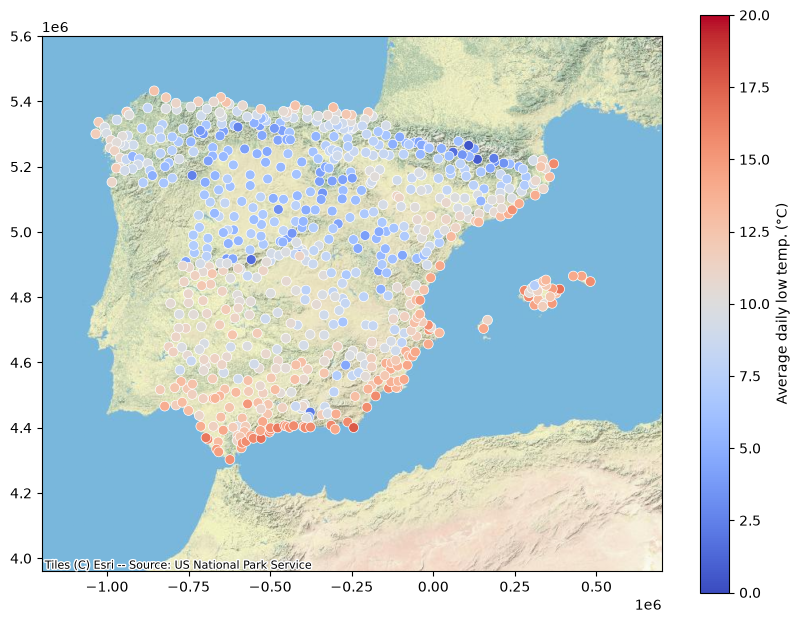

In [10]:
low_threshold = 0
high_threshold = 20

data_points = gpd.GeoDataFrame(
    station_metrics,
    geometry=gpd.points_from_xy(station_metrics["lon"], station_metrics["lat"]),
    crs=4326,
).to_crs(epsg=3857)

ax = MAP.plot(figsize=(10, 10), alpha=0.5, edgecolor='black')

data_points.plot(
    ax=ax,
    column='tmin',
    cmap='coolwarm',
    vmin=low_threshold,
    vmax=high_threshold,
    markersize=50,
    edgecolor='white',
    linewidth=0.5,
    missing_kwds={'color': 'lightgray', 'edgecolor': 'white'}
)

ax.set_xlim([-1200000, 700000])
ax.set_ylim([3960000, 5600000])

ctx.add_basemap(ax, source=ctx.providers.Esri.WorldPhysical)

sm = plt.cm.ScalarMappable(norm=Normalize(vmin=low_threshold, vmax=high_threshold), cmap='coolwarm')
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Average daily low temp. (°C)", shrink=0.75)

plt.show()

### Average daily high temperatures

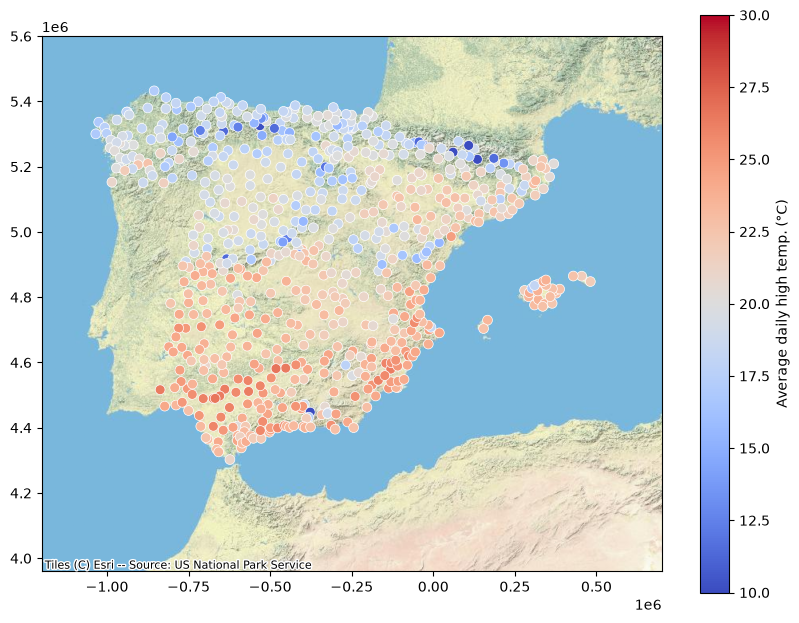

In [15]:
low_threshold = 10
high_threshold = 30

data_points = gpd.GeoDataFrame(
    station_metrics,
    geometry=gpd.points_from_xy(station_metrics["lon"], station_metrics["lat"]),
    crs=4326,
).to_crs(epsg=3857)

ax = MAP.plot(figsize=(10, 10), alpha=0.5, edgecolor='black')

data_points.plot(
    ax=ax,
    column='tmax',
    cmap='coolwarm',
    vmin=low_threshold,
    vmax=high_threshold,
    markersize=50,
    edgecolor='white',
    linewidth=0.5,
    missing_kwds={'color': 'lightgray', 'edgecolor': 'white'}
)

ax.set_xlim([-1200000, 700000])
ax.set_ylim([3960000, 5600000])

ctx.add_basemap(ax, source=ctx.providers.Esri.WorldPhysical)

sm = plt.cm.ScalarMappable(norm=Normalize(vmin=low_threshold, vmax=high_threshold), cmap='coolwarm')
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Average daily high temp. (°C)", shrink=0.75)

plt.show()

### Average daily mean temperatures

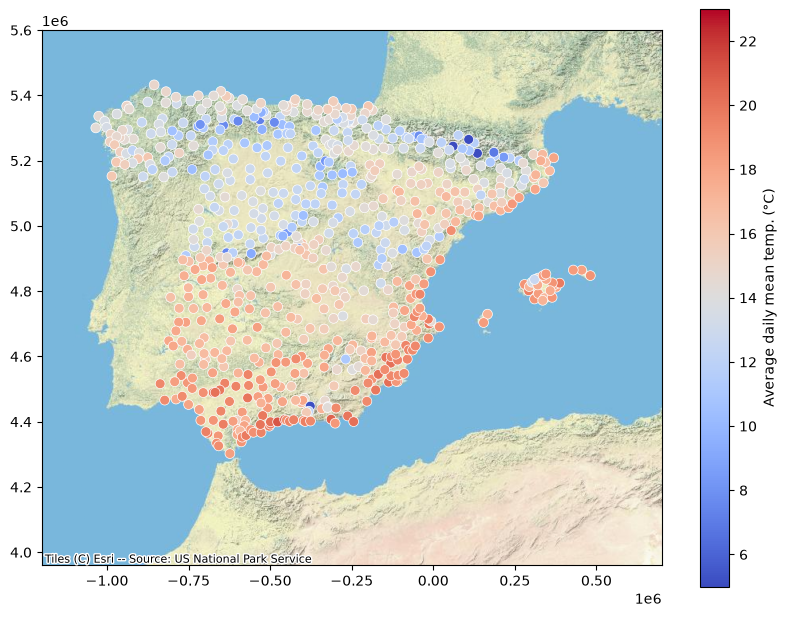

In [19]:
low_threshold = 5
high_threshold = 23

data_points = gpd.GeoDataFrame(
    station_metrics,
    geometry=gpd.points_from_xy(station_metrics["lon"], station_metrics["lat"]),
    crs=4326,
).to_crs(epsg=3857)

ax = MAP.plot(figsize=(10, 10), alpha=0.5, edgecolor='black')

data_points.plot(
    ax=ax,
    column='tmed',
    cmap='coolwarm',
    vmin=low_threshold,
    vmax=high_threshold,
    markersize=50,
    edgecolor='white',
    linewidth=0.5,
    missing_kwds={'color': 'lightgray', 'edgecolor': 'white'}
)

ax.set_xlim([-1200000, 700000])
ax.set_ylim([3960000, 5600000])

ctx.add_basemap(ax, source=ctx.providers.Esri.WorldPhysical)

sm = plt.cm.ScalarMappable(norm=Normalize(vmin=low_threshold, vmax=high_threshold), cmap='coolwarm')
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Average daily mean temp. (°C)", shrink=0.75)

plt.show()